# Data Engineering Responsibilities

**Owner:** Xavier Albino | Data Engineer  
**Course:** 2606 Data Ecosystems and Governance in Organizations

This notebook fulfills the Data Engineer role for the NovaCred Credit Application Governance Audit. It is organized by **data quality dimensions** (Completeness, Uniqueness, Consistency, Validity, Accuracy, Timeliness) as required by the assignment, with each section mapping our analysis to the corresponding dimension.

## Table of Contents

| Section | Description |
|---------|-------------|
| [1. Setup and Data Loading](#1-setup-and-data-loading) | Imports, loading, normalization |
| [2. Data Quality Assessment](#2-data-quality-assessment) | Six dimensions: completeness, uniqueness, consistency, validity, accuracy, timeliness |
| [2.1 Completeness](#21-completeness) | Hidden blanks, missing records, required vs optional, conditional |
| [2.2 Uniqueness](#22-uniqueness) | Duplicate _id and SSN, deduplication |
| [2.3 Consistency](#23-consistency) | Data types, schema, gender, date formats |
| [2.4 Validity](#24-validity) | Invalid values, email format, business rules |
| [2.5 Accuracy](#25-accuracy) | Age sanity check |
| [2.6 Timeliness](#26-timeliness) | Processing timestamp coverage |
| [3. Summary of Data Quality Issues](#3-summary-of-data-quality-issues) | Issues by dimension, visualisation, cleaning summary |
| [4. Export Cleaned Dataset](#4-export-cleaned-dataset) | Save cleaned dataset to CSV |

<a id='1-setup-and-data-loading'></a>

# 1. Setup and Data Loading

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
def summarize_issue(mask: pd.Series, label: str) -> pd.DataFrame:
    """Count records matching a boolean mask and return a small summary table."""
    n = int(mask.sum())
    total = int(mask.shape[0])
    pct = (n / total * 100) if total else 0.0
    return pd.DataFrame([{
        "issue": label,
        "affected_records": n,
        "percentage": round(pct, 2)
    }])

The raw dataset contains 500+ credit applications in nested JSON format. Below we load the file and inspect its structure.

In [3]:
DATA_PATH = Path("../data/raw_credit_applications.json")

with DATA_PATH.open("r", encoding="utf-8") as f:
    raw = json.load(f)

print("Records:", len(raw))
print("Top-level type:", type(raw))
print("Keys in first record:", list(raw[0].keys()))

Records: 502
Top-level type: <class 'list'>
Keys in first record: ['_id', 'applicant_info', 'financials', 'spending_behavior', 'decision', 'processing_timestamp']


Flatten the nested JSON to a tabular format for analysis. The schema uses dot notation for nested keys (e.g. `applicant_info.email`).

In [4]:
df = pd.json_normalize(raw, sep=".")
print("Shape:", df.shape)
df.head(3)


Shape: (502, 21)


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036,...,23,0.20,31212,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,M,1992-03-31,10032,...,51,0.18,17915,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075,...,41,0.21,37909,True,NaN,vacation,3.7,59000.0,NaN,NaN


<a id='2-data-quality-assessment'></a>

# 2. Data Quality Assessment

This section evaluates the dataset across the six data quality dimensions required by the assignment: **Completeness**, **Uniqueness**, **Consistency**, **Validity**, **Accuracy**, and **Timeliness**.

**Reproducibility:** For reproducible results, run all cells in order. Section 2.2 re-loads raw data and applies the pipeline from blank-handling onward; running cells out of order may produce inconsistent state.

---

<a id='21-completeness'></a>

## 2.1 Completeness

*Completeness* measures whether required data is present and whether conditionally required fields are populated when applicable. We first fix hidden blanks that distort missingness counts, then assess missing records, required vs optional fields, and conditional completeness on the normalized data (before deduplication and consistency cleaning).

### 2.1.1 Hidden Blank Strings

`isna()` alone does not catch fields that are present in the JSON but contain an empty string `""`. We detect these **hidden blanks** first and replace them with `NaN`, so that all downstream completeness and validity checks reflect true missingness rather than an artificially clean picture.

In [5]:
hidden_blank_detail = {}
n_hidden_blanks     = 0

for _col in df.select_dtypes(include="object").columns:
    n_blank = int(
        (df[_col].fillna("").str.strip() == "").sum()
        - df[_col].isna().sum()
    )
    if n_blank > 0:
        hidden_blank_detail[_col] = n_blank
        n_hidden_blanks += n_blank

print(f"Hidden blank strings (present but empty, missed by isna): {n_hidden_blanks}")
if hidden_blank_detail:
    print(f"  {'Field':<44}  {'Count':>6}")
    print("  " + "-" * 54)
    for _col, _n in sorted(hidden_blank_detail.items(), key=lambda x: -x[1]):
        print(f"  {_col:<44}  {_n:>6}")

# Normalise: strip whitespace then replace empty strings with NaN
for _col in df.select_dtypes(include="object").columns:
    df[_col] = df[_col].apply(lambda x: x.strip() if isinstance(x, str) else x)
    df[_col] = df[_col].replace("", float("nan"))

print(f"\n{n_hidden_blanks} blank strings replaced with NaN; all subsequent checks reflect true missingness.")

Hidden blank strings (present but empty, missed by isna): 14
  Field                                          Count
  ------------------------------------------------------
  applicant_info.email                               7
  applicant_info.date_of_birth                       4
  applicant_info.gender                              2
  applicant_info.zip_code                            1

14 blank strings replaced with NaN; all subsequent checks reflect true missingness.


**Interpretation:** The output shows that 14 values were stored as empty strings (e.g. in `applicant_info.email`, `applicant_info.date_of_birth`, `applicant_info.gender`, `applicant_info.zip_code`) and would have been missed by `isna()` alone. By replacing them with `NaN`, all later completeness and validity checks treat these as truly missing, giving an accurate picture of data quality.

### 2.1.2 Missing and incomplete records

We assess missing records, required vs optional fields, and conditional completeness on the **normalized data after the hidden-blank fix** (above). Row counts are for the full normalized dataset; no rows have been removed yet.


In [6]:
# Records missing ≥2 key financial fields (completeness flag)
financial_cols = [
    "financials.annual_income", "financials.credit_history_months",
    "financials.debt_to_income", "financials.savings_balance"
]
df["_missing_critical_financials"] = df[financial_cols].isna().sum(axis=1)
display(summarize_issue(df["_missing_critical_financials"] >= 2, "Records missing ≥2 key financial fields"))

,issue,affected_records,percentage
0,Records missing ≥2 key financial fields,0,0.0


**Interpretation:** This table counts how many records are missing two or more of the key financial fields (`annual_income`, `credit_history_months`, `debt_to_income`, `savings_balance`). Here the count is 0, so no records are flagged for review on this criterion. Records that did meet the threshold would be flagged for review rather than imputed, to avoid bias in governance-sensitive analysis.

In [7]:
missing_summary = (
    df.isna()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / len(df) * 100
).round(2)

missing_summary.sort_values("missing_percentage", ascending=False)

,missing_count,missing_percentage
notes,500,99.60
financials.annual_salary,497,99.00
loan_purpose,452,90.04
processing_timestamp,440,87.65
decision.rejection_reason,292,58.17
decision.approved_amount,210,41.83
decision.interest_rate,210,41.83
applicant_info.email,7,1.39
applicant_info.ssn,5,1.00
applicant_info.ip_address,5,1.00


**Interpretation:** The table shows per-column missing counts and percentages (sorted by missing rate). The highest missing rates are in metadata or optional fields (e.g. `notes`, `financials.annual_salary`, `loan_purpose`, `processing_timestamp`, `decision.rejection_reason`, `decision.approved_amount`, `decision.interest_rate`). Core identifiers and key financial fields (`_id`, `financials.credit_history_months`, `decision.loan_approved`, `financials.savings_balance`, `financials.debt_to_income`) are complete or nearly so, which supports using this dataset for modeling with minimal completeness-related bias.

### 2.1.3 Required vs Optional Fields

Required fields must be non-null for every record; optional fields may be missing. This table classifies each field and reports OK/ISSUE based on whether required fields meet completeness expectations.

In [8]:
# Required vs optional field definitions
REQUIRED_FIELDS = [
    "_id", "applicant_info.full_name", "applicant_info.email", "applicant_info.ssn",
    "applicant_info.date_of_birth", "applicant_info.gender", "applicant_info.zip_code",
    "financials.credit_history_months", "financials.debt_to_income", "financials.savings_balance",
    "decision.loan_approved",
]
OPTIONAL_FIELDS = [
    "applicant_info.ip_address", "financials.annual_income", "financials.annual_salary",
    "loan_purpose", "decision.interest_rate", "decision.approved_amount",
    "decision.rejection_reason", "processing_timestamp", "notes", "spending_behavior",
]
OPTIONAL_ISSUE_PCT = 50  # flag optional fields with >50% missing as ISSUE

cols = [c for c in REQUIRED_FIELDS + OPTIONAL_FIELDS if c in df.columns]
n_total = len(df)
rows = [
    {
        "field": col,
        "type": "required" if col in REQUIRED_FIELDS else "optional",
        "missing_count": int(df[col].isna().sum()),
        "missing_pct": round(df[col].isna().sum() / n_total * 100, 2),
    }
    for col in cols
]
completeness_table = pd.DataFrame(rows)
completeness_table["status"] = completeness_table.apply(
    lambda r: "OK" if (r["type"] == "required" and r["missing_count"] == 0) or (r["type"] == "optional" and r["missing_pct"] <= OPTIONAL_ISSUE_PCT) else "ISSUE",
    axis=1,
)
display(completeness_table)

,field,type,missing_count,missing_pct,status
0,_id,required,0,0.00,OK
1,applicant_info.full_name,required,0,0.00,OK
2,applicant_info.email,required,7,1.39,ISSUE
3,applicant_info.ssn,required,5,1.00,ISSUE
4,applicant_info.date_of_birth,required,5,1.00,ISSUE
5,applicant_info.gender,required,3,0.60,ISSUE
6,applicant_info.zip_code,required,2,0.40,ISSUE
7,financials.credit_history_months,required,0,0.00,OK
8,financials.debt_to_income,required,0,0.00,OK
9,financials.savings_balance,required,0,0.00,OK


**Interpretation:** The table shows that several required applicant fields (email, SSN, date_of_birth, gender, zip_code) have a small number of missing values (ISSUE), while core financial and decision fields are complete. Optional fields with very high missingness (e.g. `notes`, `financials.annual_salary`, `loan_purpose`) are correctly classified as optional and flagged as ISSUE where their missing rate exceeds the threshold.

### 2.1.4 Conditional Completeness: Decision Field Integrity

Each loan outcome implies a specific set of fields that must (or must not) be populated:
- **Approved** → `approved_amount` and `interest_rate` must be present; `rejection_reason` must be absent
- **Rejected** → `rejection_reason` must be present; `approved_amount` and `interest_rate` must be absent

Violations indicate **structural incoherence** between the decision and its supporting data. This is a consistency failure that would silently corrupt downstream modelling and any regulatory audit of the decision-making process.

In [9]:
approved = df["decision.loan_approved"] == True
rejected = ~approved

integrity_checks = [
    ("Approved: approved_amount missing", approved & df["decision.approved_amount"].isna()),
    ("Approved: interest_rate missing", approved & df["decision.interest_rate"].isna()),
    ("Approved: rejection_reason present", approved & df["decision.rejection_reason"].notna()),
    ("Rejected: rejection_reason missing", rejected & df["decision.rejection_reason"].isna()),
    ("Rejected: approved_amount present", rejected & df["decision.approved_amount"].notna()),
    ("Rejected: interest_rate present", rejected & df["decision.interest_rate"].notna()),
]

integrity_df = pd.DataFrame([
    {"check": label, "violations": int(mask.sum()), "status": "OK" if mask.sum() == 0 else "ISSUE"}
    for label, mask in integrity_checks
])
display(integrity_df)

total_violations = integrity_df["violations"].sum()
print("All decision-field integrity checks pass." if total_violations == 0 else f"Total violations: {int(total_violations)}")

,check,violations,status
0,Approved: approved_amount missing,0,OK
1,Approved: interest_rate missing,0,OK
2,Approved: rejection_reason present,0,OK
3,Rejected: rejection_reason missing,0,OK
4,Rejected: approved_amount present,0,OK
5,Rejected: interest_rate present,0,OK


All decision-field integrity checks pass.


**Interpretation:** Zero violations across all checks means the decision data is structurally consistent: every approved record has the expected decision fields filled, and every rejected record has the expected pattern. This is important for downstream modeling and for regulatory audit of the decision process.

<a id='22-uniqueness'></a>

## 2.2 Uniqueness

**Dimension:** Uniqueness — duplicate identifiers or repeated entities.

### 2.2.1 Duplicate application IDs (_id)


In [10]:
# Columns available after normalization (for reference)
df.columns.tolist()

['_id',
 'spending_behavior',
 'processing_timestamp',
 'applicant_info.full_name',
 'applicant_info.email',
 'applicant_info.ssn',
 'applicant_info.ip_address',
 'applicant_info.gender',
 'applicant_info.date_of_birth',
 'applicant_info.zip_code',
 'financials.annual_income',
 'financials.credit_history_months',
 'financials.debt_to_income',
 'financials.savings_balance',
 'decision.loan_approved',
 'decision.rejection_reason',
 'loan_purpose',
 'decision.interest_rate',
 'decision.approved_amount',
 'financials.annual_salary',
 'notes',
 '_missing_critical_financials']

Each application ID (`_id`) must uniquely identify one credit application. Duplicate IDs indicate either a system ingestion error or a resubmission by the same applicant. We identify all duplicate groups and inspect them before deciding which record to retain.

In [11]:
def dedupe_keep_one(df, key_col, notes_col="notes", error_val="DUPLICATE_ENTRY_ERROR", resubmit_val="RESUBMISSION"):
    """For each duplicate key: if notes==error_val → keep most complete; if notes==resubmit_val → keep latest; else most complete. Returns (df_deduped, list of removed indices)."""
    dup_mask = df[key_col].duplicated(keep=False)
    if df[key_col].dtype == "object" and df[key_col].notna().any():
        dup_mask = dup_mask & df[key_col].notna()
    keys = df.loc[dup_mask, key_col].unique()
    remove_idx = []
    for k in keys:
        g = df.loc[df[key_col] == k]
        if error_val and (g[notes_col] == error_val).any():
            idx_keep = g.isna().sum(axis=1).idxmin()
        elif resubmit_val and (g[notes_col] == resubmit_val).any():
            idx_keep = g.index.max()
        else:
            idx_keep = g.isna().sum(axis=1).idxmin()
        remove_idx.extend([i for i in g.index if i != idx_keep])
    return df.drop(index=remove_idx).copy(), remove_idx

# Reload raw and apply hidden-blank fix (pipeline start for 2.2+)
with DATA_PATH.open("r", encoding="utf-8") as f:
    raw_original = json.load(f)
df_original = pd.json_normalize(raw_original, sep=".")
for _col in df_original.select_dtypes(include="object").columns:
    df_original[_col] = df_original[_col].apply(lambda x: x.strip() if isinstance(x, str) else x)
    df_original[_col] = df_original[_col].replace("", float("nan"))

# 2.2.1 Deduplicate by _id (DUPLICATE_ENTRY_ERROR → keep most complete; else keep latest)
dup_id_mask = df_original["_id"].duplicated(keep=False)
display(summarize_issue(dup_id_mask, "Duplicate application IDs (_id)"))
df_clean, remove_idx = dedupe_keep_one(df_original, "_id")
print(f"Rows: {len(df_original)} → {len(df_clean)} (removed {len(remove_idx)}). Duplicate _id remaining: {df_clean['_id'].duplicated(keep=False).sum()}.")

,issue,affected_records,percentage
0,Duplicate application IDs (_id),4,0.8


Rows: 502 → 500 (removed 2). Duplicate _id remaining: 0.


### 2.2.2 Duplicate SSN (business-level)

In [12]:
# Duplicate SSN in raw (before _id dedup): count and list
dup_ssn_mask_raw = (
    df_original["applicant_info.ssn"].duplicated(keep=False)
    & df_original["applicant_info.ssn"].notna()
)
display(summarize_issue(dup_ssn_mask_raw, "Duplicate SSN in RAW"))
dup_ssns_raw = df_original.loc[dup_ssn_mask_raw, "applicant_info.ssn"].unique()
if len(dup_ssns_raw) > 0:
    print("Duplicated SSNs in RAW:", list(dup_ssns_raw))
    display(df_original[df_original["applicant_info.ssn"].isin(dup_ssns_raw)].sort_values("applicant_info.ssn")[["_id", "applicant_info.full_name", "applicant_info.ssn", "notes"]])

,issue,affected_records,percentage
0,Duplicate SSN in RAW,6,1.2


Duplicated SSNs in RAW: ['652-70-5530', '937-72-8731', '780-24-9300']


,_id,applicant_info.full_name,applicant_info.ssn,notes
8,app_042,Joseph Lopez,652-70-5530,NaN
354,app_042,Joseph Lopez,652-70-5530,RESUBMISSION
92,app_088,Susan Martinez,780-24-9300,NaN
122,app_016,Gary Wilson,780-24-9300,NaN
16,app_101,Sandra Smith,937-72-8731,NaN
499,app_234,Samuel Hill,937-72-8731,NaN


In [13]:
# 2.2.2 Deduplicate by SSN on df_clean (same rule: RESUBMISSION → latest, else most complete)
df_final = df_clean.copy()
dup_ssn_mask = (
    df_final["applicant_info.ssn"].duplicated(keep=False)
    & df_final["applicant_info.ssn"].notna()
)
display(summarize_issue(dup_ssn_mask, "Duplicate SSN (on df_clean, before cleaning)"))
df_final, ssn_removed = dedupe_keep_one(df_final, "applicant_info.ssn")
print(f"Rows: {len(df_clean)} → {len(df_final)} (removed {len(ssn_removed)}). Duplicate SSN remaining: {(df_final['applicant_info.ssn'].duplicated(keep=False) & df_final['applicant_info.ssn'].notna()).sum()}.")

,issue,affected_records,percentage
0,"Duplicate SSN (on df_clean, before cleaning)",4,0.8


Rows: 500 → 498 (removed 2). Duplicate SSN remaining: 0.


**Interpretation:** The summary shows duplicate SSN count on `df_clean` before cleaning (e.g. 4 rows, 0.8%). We apply the same rule as for _id: RESUBMISSION → keep latest; otherwise keep most complete. Rows go 500 → 498; no duplicate SSNs remain in `df_final`. In raw there were 6 rows (3 SSNs); after _id dedup one SSN pair was already removed, so only 4 rows remained to clean here.

<a id='23-consistency'></a>

## 2.3 Consistency

**Dimension:** Consistency — same data represented in different formats or encodings.

We cover four areas: **Income variables**, **Datetime fields**, **Gender**, and **Date of birth**. For each we show the distribution (types or counts) and then how we handle it in the cleaned dataset.

### 2.3.1 Income variables

Distribution: types present in `financials.annual_income` and overlap with `financials.annual_salary` (same concept, two field names).

Types in financials.annual_income: [<class 'int'> <class 'str'> <class 'float'>]
Mixed types? True

Schema overlap (same concept, two field names):
  financials.annual_salary (non-null) : 5 records
  financials.annual_income (null)    : 5 records


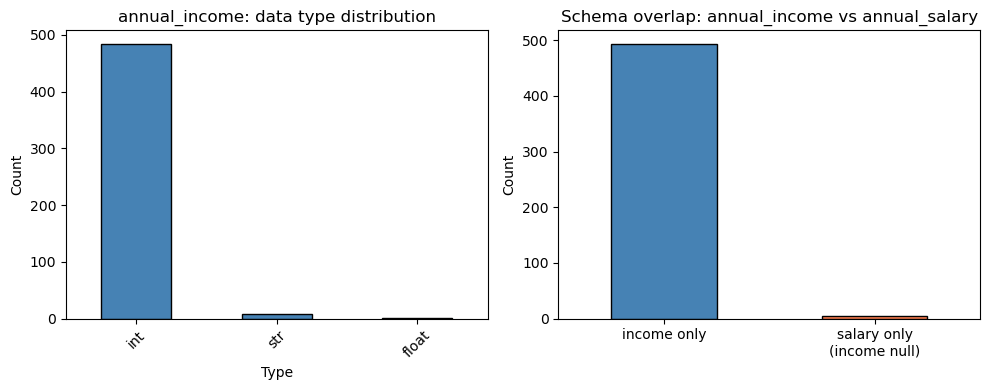

,_id,applicant_info.full_name,financials.annual_income,financials.annual_salary
76,app_436,Amanda Torres,NaN,45000.0
94,app_421,Donald Baker,NaN,46000.0
99,app_479,Sandra Jones,NaN,94000.0
141,app_463,Emma Clark,NaN,86000.0
149,app_449,Lisa Roberts,NaN,75000.0


In [14]:
# Distribution: types in annual_income and overlap with annual_salary
col = "financials.annual_income"
type_counts = df_final[col].dropna().map(lambda x: type(x).__name__).value_counts()
salary_present = int(df_final["financials.annual_salary"].notna().sum())
income_null = int(df_final["financials.annual_income"].isna().sum())
income_only = int(((df_final[col].notna()) & (df_final["financials.annual_salary"].isna())).sum())

print("Types in financials.annual_income:", df_final[col].dropna().map(type).unique())
print("Mixed types?", len(type_counts) > 1)
print()
print("Schema overlap (same concept, two field names):")
print(f"  financials.annual_salary (non-null) : {salary_present} records")
print(f"  financials.annual_income (null)    : {income_null} records")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
type_counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("annual_income: data type distribution")
axes[0].set_xlabel("Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)
schema_counts = pd.Series({"income only": income_only, "salary only\n(income null)": salary_present})
schema_counts.plot(kind="bar", ax=axes[1], color=["steelblue", "coral"], edgecolor="black")
axes[1].set_title("Schema overlap: annual_income vs annual_salary")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

if salary_present > 0:
    cols_show = ["_id", "applicant_info.full_name", "financials.annual_income", "financials.annual_salary"]
    display(df_final[df_final["financials.annual_salary"].notna()][cols_show])

In [15]:
# Handling: coerce to numeric, merge annual_salary into annual_income where null, then drop annual_salary
col = "financials.annual_income"
missing_before = df_final[col].isna().sum()
df_final["financials.annual_income"] = pd.to_numeric(df_final["financials.annual_income"], errors="coerce")
df_final["financials.annual_income"] = df_final["financials.annual_income"].fillna(df_final["financials.annual_salary"])
df_final = df_final.drop(columns=["financials.annual_salary"])
missing_after = df_final["financials.annual_income"].isna().sum()
n_merged = int(missing_before - missing_after)
print(f"Coerced to numeric; {n_merged} null(s) filled from annual_salary. Dropped annual_salary.")
print(f"annual_income null count: {int(missing_before)} → {int(missing_after)}")

Coerced to numeric; 5 null(s) filled from annual_salary. Dropped annual_salary.
annual_income null count: 5 → 0


**Interpretation:** `financials.annual_income` had mixed types (int, float, string). We coerce to numeric and merge `annual_salary` into `annual_income` where income was null (same concept, two field names), then drop `annual_salary`. One consistent income field remains for downstream analysis. A single income field also avoids pipelines silently excluding records that only had `annual_salary`.

### 2.3.2 Datetime fields

Distribution: timestamp present/missing; date_of_birth format breakdown on raw data.

Processing timestamp: present 62 (12.4%), missing 440

Date-of-birth format (RAW):
  YYYY-MM-DD (ISO): 340
  DD/MM/YYYY or MM/DD/YYYY: 101
  YYYY/MM/DD: 56
  empty / null: 5
  Non-ISO (need parsing): 162


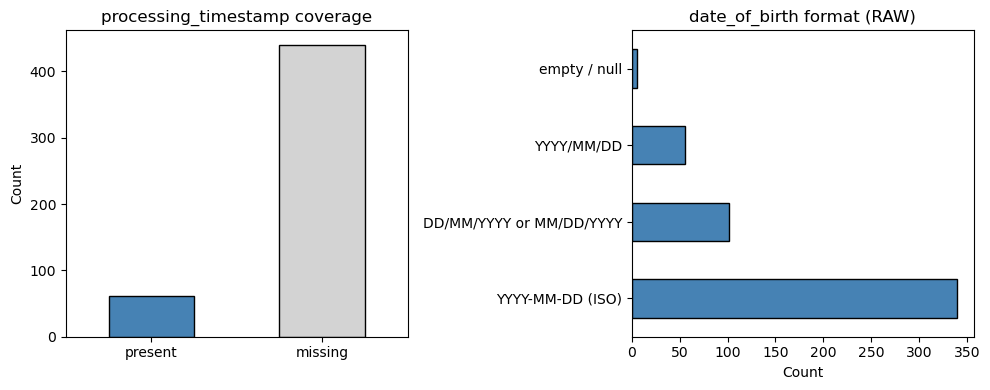

In [16]:
# Distribution: timestamp coverage and DoB format classification (RAW)
import re as _re_dob
_ISO_RE_DOB = _re_dob.compile(r"^\d{4}-\d{2}-\d{2}$")

def _classify_dob(d):
    if not isinstance(d, str) or d.strip() == "":
        return "empty / null"
    if _ISO_RE_DOB.match(d):
        return "YYYY-MM-DD (ISO)"
    if _re_dob.match(r"^\d{4}/\d{2}/\d{2}$", d):
        return "YYYY/MM/DD"
    if _re_dob.match(r"^\d{2}/\d{2}/\d{4}$", d):
        return "DD/MM/YYYY or MM/DD/YYYY"
    return "other"

ts_col = "processing_timestamp"
ts_present = df_original[ts_col].notna().sum()
ts_missing = df_original[ts_col].isna().sum()
total = len(df_original)
print("Processing timestamp: present", int(ts_present), f"({ts_present/total*100:.1f}%), missing", int(ts_missing))
print()
dob_fmt = df_original["applicant_info.date_of_birth"].apply(_classify_dob)
fmt_counts = dob_fmt.value_counts()
print("Date-of-birth format (RAW):")
for fmt, cnt in fmt_counts.items():
    print(f"  {fmt}: {cnt}")
print("  Non-ISO (need parsing):", int((dob_fmt != "YYYY-MM-DD (ISO)").sum()))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ts_dist = pd.Series({"present": int(ts_present), "missing": int(ts_missing)})
ts_dist.plot(kind="bar", ax=axes[0], color=["steelblue", "lightgray"], edgecolor="black")
axes[0].set_title("processing_timestamp coverage")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
fmt_counts.plot(kind="barh", ax=axes[1], color="steelblue", edgecolor="black")
axes[1].set_title("date_of_birth format (RAW)")
axes[1].set_xlabel("Count")
plt.tight_layout()
plt.show()

In [17]:
# Handling: convert processing_timestamp and date_of_birth to datetime, write to df_final
df_final["processing_timestamp"] = pd.to_datetime(
    df_final["processing_timestamp"], errors="coerce", utc=True
)
dob_raw = df_final["applicant_info.date_of_birth"].astype(str).replace(["nan", ""], pd.NA)
dob_raw = dob_raw.where(dob_raw.notna() & (dob_raw != "<NA>"), pd.NA)
dob_parsed = pd.to_datetime(dob_raw, errors="coerce")
still_na = dob_parsed.isna() & dob_raw.notna()
if still_na.any():
    dob_parsed = dob_parsed.fillna(pd.to_datetime(dob_raw[still_na], errors="coerce", dayfirst=True))
failed_dob = dob_parsed.isna() & dob_raw.notna()
display(summarize_issue(failed_dob, "Unparseable date_of_birth (after cleaning)"))
df_final["applicant_info.date_of_birth"] = dob_parsed
display(df_final[["processing_timestamp", "applicant_info.date_of_birth"]].dtypes)

/var/folders/5_/r_dplqns0ql9kmrvcqtcdq600000gn/T/ipykernel_62967/3776724390.py:7: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  dob_parsed = pd.to_datetime(dob_raw, errors="coerce")


,issue,affected_records,percentage
0,Unparseable date_of_birth (after cleaning),0,0.0


processing_timestamp            datetime64[ns, UTC]
applicant_info.date_of_birth         datetime64[ns]
dtype: object

**Interpretation:** `processing_timestamp` and `applicant_info.date_of_birth` were stored as strings. We convert timestamp to datetime with UTC, and parse date_of_birth with inference then dayfirst for mixed formats (YYYY-MM-DD, DD/MM/YYYY, YYYY/MM/DD). Both columns are now datetime for age and timeliness checks. Consistent datetime types support audit trails and timeliness assessment for governance.

### 2.3.3 Gender

Distribution: value counts before normalisation; handling: map M/F and male/female to Male/Female.

Gender before normalisation:
Male      194
Female    192
F          58
M          52
NaN         2
Name: applicant_info.gender, dtype: int64


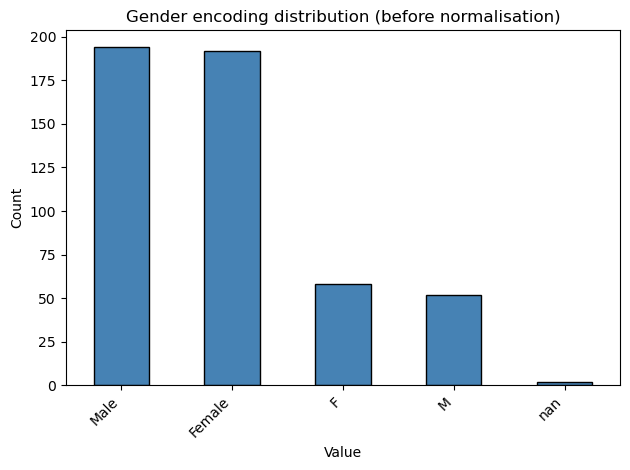

In [18]:
# Distribution: gender value counts before normalisation
gender_counts = df_final["applicant_info.gender"].value_counts(dropna=False)
print("Gender before normalisation:")
print(gender_counts)
gender_counts.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Gender encoding distribution (before normalisation)")
plt.xlabel("Value")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [19]:
# Handling: normalise to Male/Female
gender_map = {"M": "Male", "F": "Female", "male": "Male", "female": "Female"}
df_final["applicant_info.gender"] = df_final["applicant_info.gender"].replace(gender_map)
print("After normalisation:")
print(df_final["applicant_info.gender"].value_counts(dropna=False))

After normalisation:
Female    250
Male      246
NaN         2
Name: applicant_info.gender, dtype: int64


**Interpretation:** Gender was stored as both M/F and Male/Female. We normalise to Male/Female so bias and fairness analysis use a single encoding. Unified encoding also supports governance and fairness reporting.

### 2.3.4 Date of birth (formats and parsing)

Distribution: format classification on raw data; unparseable count under a single strict parser. Parsing is applied in 2.3.2 above.

,count
YYYY-MM-DD (ISO),340
DD/MM/YYYY or MM/DD/YYYY,101
YYYY/MM/DD,56
empty / null,5


,issue,affected_records,percentage
0,Unparseable under strict parser (RAW),497,99.0


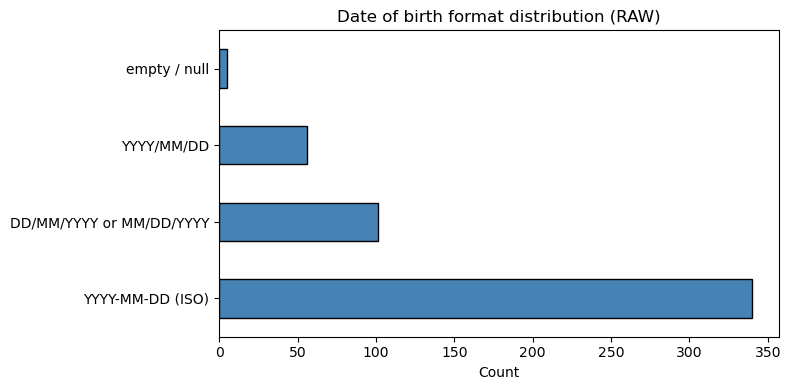

In [20]:
# Format classification on RAW (reuse _classify_dob from 2.3.2); unparseable under strict parser
dob_raw_orig = df_original["applicant_info.date_of_birth"]
fmt_series = dob_raw_orig.apply(_classify_dob)
fmt_counts_dob = fmt_series.value_counts()
display(fmt_counts_dob.to_frame("count"))
dob_strict = pd.to_datetime(dob_raw_orig, errors="coerce", format="mixed")
failed_strict = dob_strict.isna() & dob_raw_orig.notna()
display(summarize_issue(failed_strict, "Unparseable under strict parser (RAW)"))

fig, ax = plt.subplots(figsize=(8, 4))
fmt_counts_dob.plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Date of birth format distribution (RAW)")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

**Interpretation:** Raw `date_of_birth` has mixed formats (ISO, DD/MM/YYYY, YYYY/MM/DD). A single strict parser leaves many unparseable; the two-step parsing (inference + dayfirst) in 2.3.2 resolves this in the cleaned dataset. Clear format handling supports auditability and downstream age checks.

<a id='24-validity'></a>

## 2.4 Validity

**Dimension:** Validity — values conform to allowed rules, formats, and business constraints.

We cover three areas: **Numeric ranges**, **Email format**, and **Process control** (approved loans with missing income). For each we show the distribution (counts and chart), how we handle it, and an interpretation.

### 2.4.1 Invalid numeric values and ranges

Values that violate allowed ranges (e.g. negative credit history, DTI outside [0, 1.5], negative savings) are flagged. Records are retained for audit; remediation would route them to a data steward.

,issue,affected_records,percentage
0,Negative credit_history_months,2,0.4
1,"Debt-to-income outside [0, 1.5]",1,0.2
2,Negative savings_balance,1,0.2


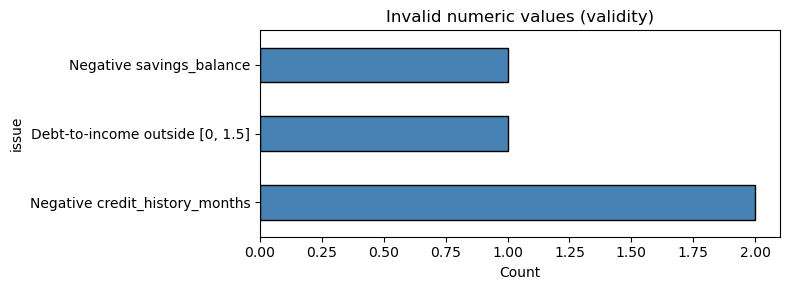

Remediation (set to NaN):
  Negative credit_history_months: 2 → 0
  Negative savings_balance:        1 → 0
  DTI outside [0, 1.5]:           1 → 0


In [21]:
# Distribution: invalid numeric values; then remediate (set impossible values to NaN)
issues_invalid = []
mask_ch = df_final["financials.credit_history_months"] < 0
issues_invalid.append(summarize_issue(mask_ch, "Negative credit_history_months"))
mask_dti = (df_final["financials.debt_to_income"] < 0) | (df_final["financials.debt_to_income"] > 1.5)
issues_invalid.append(summarize_issue(mask_dti, "Debt-to-income outside [0, 1.5]"))
mask_sav = df_final["financials.savings_balance"] < 0
issues_invalid.append(summarize_issue(mask_sav, "Negative savings_balance"))
invalid_summary = pd.concat(issues_invalid, ignore_index=True)
display(invalid_summary)

# Chart: validity issues by type
fig, ax = plt.subplots(figsize=(8, 3))
invalid_summary.set_index("issue")["affected_records"].plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Invalid numeric values (validity)")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

# Handling: set impossible values to NaN
ch_col = "financials.credit_history_months"
sb_col = "financials.savings_balance"
dti_col = "financials.debt_to_income"
n_neg_ch_before = int((df_final[ch_col] < 0).sum())
n_neg_sb_before = int((df_final[sb_col] < 0).sum())
dti_bad = (df_final[dti_col].lt(0) | df_final[dti_col].gt(1.5)) & df_final[dti_col].notna()
n_dti_bad_before = int(dti_bad.sum())
df_final.loc[df_final[ch_col] < 0, ch_col] = np.nan
df_final.loc[df_final[sb_col] < 0, sb_col] = np.nan
df_final.loc[dti_bad, dti_col] = np.nan
n_neg_ch_after = int((df_final[ch_col] < 0).sum())
n_neg_sb_after = int((df_final[sb_col] < 0).sum())
n_dti_bad_after = int(((df_final[dti_col].lt(0) | df_final[dti_col].gt(1.5)) & df_final[dti_col].notna()).sum())
print("Remediation (set to NaN):")
print(f"  Negative credit_history_months: {n_neg_ch_before} → {n_neg_ch_after}")
print(f"  Negative savings_balance:        {n_neg_sb_before} → {n_neg_sb_after}")
print(f"  DTI outside [0, 1.5]:           {n_dti_bad_before} → {n_dti_bad_after}")

### 2.4.2 Email Format Validity

A valid email must match the pattern `local@domain.tld`. Records with non-null but malformed emails indicate a validation gap at data entry. Distribution and flagging below.

In [22]:
import re as _re_email

_email_re   = _re_email.compile(r"^[^@\s]+@[^@\s]+\.[^@\s]+$")
email_col   = "applicant_info.email"
emails_nn   = df_final[email_col].dropna()
bad_emails  = emails_nn[~emails_nn.apply(lambda v: bool(_email_re.match(str(v))))]

print("Email Format Validity:")
print(f"  Emails present    : {len(emails_nn)}")
n_invalid = len(bad_emails)
n_valid = len(emails_nn) - n_invalid
print(f"  Format violations : {n_invalid}")
if len(bad_emails) > 0:
    print()
    show = df_final[df_final[email_col].isin(bad_emails)][
        ["_id", email_col, "decision.loan_approved"]
    ]
    for _, row in show.iterrows():
        print(f"  {row['_id']:<10}  {str(row[email_col]):<36}  approved: {row['decision.loan_approved']}")
display(summarize_issue(df_final[email_col].isin(bad_emails), "Invalid email format (validity)"))

# Remediation: set invalid emails to NaN so downstream use treats them as missing
df_final.loc[df_final[email_col].isin(bad_emails), email_col] = np.nan
print("Remediation: invalid email values set to NaN.")

Email Format Validity:
  Emails present    : 491
  Format violations : 4

  app_204     mike johnson@gmail.com                approved: False
  app_299     test.user.outlook.com                 approved: False
  app_068     john.doe@invalid                      approved: True
  app_146     sarah.smith@                          approved: True


,issue,affected_records,percentage
0,Invalid email format (validity),4,0.8


Remediation: invalid email values set to NaN.


### 2.4.3 SSN Format Validity

SSN should follow the pattern `XXX-XX-XXXX` (three digits, hyphen, two digits, hyphen, four digits). Non-null values that do not match are flagged as invalid (Validity dimension). We set invalid SSNs to NaN for consistency.

In [23]:
import re as _re_ssn
_ssn_re = _re_ssn.compile(r"^\d{3}-\d{2}-\d{4}$")
ssn_col = "applicant_info.ssn"
ssn_nn = df_final[ssn_col].dropna().astype(str)
invalid_ssn_mask = ~ssn_nn.str.match(_ssn_re)
n_invalid_ssn = int(invalid_ssn_mask.sum())
# Apply to full frame for summarize_issue
invalid_ssn_full = df_final[ssn_col].notna() & ~df_final[ssn_col].astype(str).str.match(_ssn_re, na=False)
display(summarize_issue(invalid_ssn_full, "Invalid SSN format (validity)"))
if n_invalid_ssn > 0:
    df_final.loc[invalid_ssn_full, ssn_col] = np.nan
    print("Remediation: invalid SSN values set to NaN.")

,issue,affected_records,percentage
0,Invalid SSN format (validity),0,0.0


### 2.4.4 Zip Code Validity

US zip codes are 5 digits or 5+4 (ZIP+4). We flag non-null values that are not numeric strings of length 5 or 9 (or 10 with hyphen) as invalid (Validity dimension). Invalid zip codes are set to NaN.

In [24]:
zip_col = "applicant_info.zip_code"
zip_nn = df_final[zip_col].dropna().astype(str).str.strip()
# Valid: 5 digits or 9 digits (optionally with hyphen)
zip_valid = zip_nn.str.match(r"^\d{5}(-\d{4})?$")
invalid_zip_mask = ~zip_valid
n_invalid_zip = int(invalid_zip_mask.sum())
invalid_zip_full = df_final[zip_col].notna() & ~df_final[zip_col].astype(str).str.strip().str.match(r"^\d{5}(-\d{4})?$", na=False)
display(summarize_issue(invalid_zip_full, "Invalid zip code format (validity)"))
if n_invalid_zip > 0:
    df_final.loc[invalid_zip_full, zip_col] = np.nan
    print("Remediation: invalid zip code values set to NaN.")

,issue,affected_records,percentage
0,Invalid zip code format (validity),0,0.0


### 2.4.5 Process Control Gap: Approved Loans With Missing Income

Basic underwriting logic requires verified income before approving a loan. Approvals where `annual_income` is absent signal a **process control failure**. Distribution and documentation below.

In [25]:
income_coerced = pd.to_numeric(df_final["financials.annual_income"], errors="coerce")
approved_mask  = df_final["decision.loan_approved"] == True
no_income_mask = income_coerced.isna() | (income_coerced <= 0)

approved_no_income = df_final[approved_mask & no_income_mask]
total_approved     = int(approved_mask.sum())
n_no_income        = len(approved_no_income)

print("Approved Loans With Zero or Missing Income:")
print(f"  Total approved loans              : {total_approved}")
print(f"  Approved with missing/zero income : {n_no_income}  ({n_no_income/total_approved*100:.1f}%)")
print()
print("  This is a process-level control gap: income validation must be enforced")
print("  at approval time. Post-hoc data cleaning cannot substitute for this.")
display(summarize_issue(approved_mask & no_income_mask, "Approved loans with missing/zero income"))


Approved Loans With Zero or Missing Income:
  Total approved loans              : 292
  Approved with missing/zero income : 0  (0.0%)

  This is a process-level control gap: income validation must be enforced
  at approval time. Post-hoc data cleaning cannot substitute for this.


,issue,affected_records,percentage
0,Approved loans with missing/zero income,0,0.0


<a id='25-accuracy'></a>

## 2.5 Accuracy

**Dimension:** Accuracy — data correctly representing real-world values.

We cover **age sanity** (derived from `date_of_birth`). We show the distribution (counts and chart), how we handle it, and an interpretation.

### 2.5.1 Age sanity check

Plausible lending age range is **18–100 years**. Implausible ages indicate data entry errors or date parsing issues.

Age Sanity Check (derived from date_of_birth):
  Records with parseable DOB       : 494
  Age range                        : 21.2 – 65.3 years
  Implausible ages (<18 or >100)   : 0
  No implausible ages detected; internal consistency is good.
  Note: full accuracy requires an external ground-truth source (e.g. credit bureau).


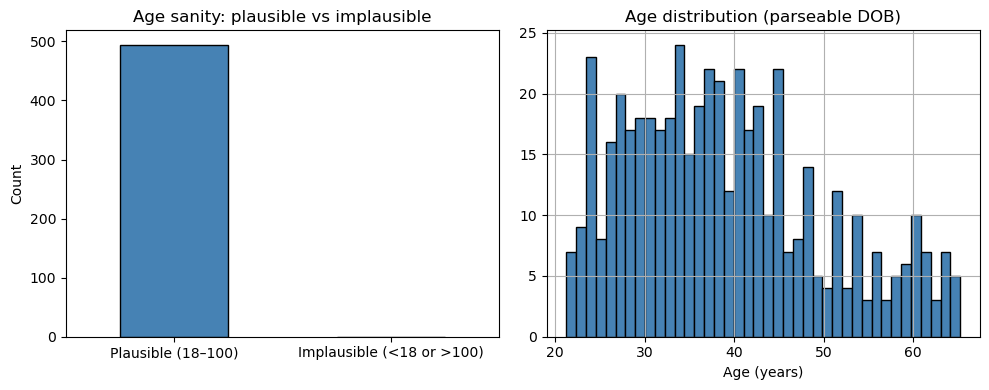

In [26]:
ref_date    = pd.Timestamp("2024-01-01")
ages_series = ((ref_date - df_final["applicant_info.date_of_birth"]).dt.days / 365.25)
ages_valid  = ages_series.dropna()

implausible_mask = (ages_series < 18) | (ages_series > 100)
n_implausible    = int(implausible_mask.sum())

print("Age Sanity Check (derived from date_of_birth):")
print(f"  Records with parseable DOB       : {len(ages_valid)}")
if len(ages_valid) > 0:
    print(f"  Age range                        : {ages_valid.min():.1f} – {ages_valid.max():.1f} years")
print(f"  Implausible ages (<18 or >100)   : {n_implausible}")

if n_implausible > 0:
    display(df_final[implausible_mask][["_id", "applicant_info.date_of_birth", "applicant_info.full_name"]])
else:
    print("  No implausible ages detected; internal consistency is good.")
    print("  Note: full accuracy requires an external ground-truth source (e.g. credit bureau).")

# Chart: distribution of age sanity (plausible vs implausible) and age histogram
n_plausible = len(ages_valid) - n_implausible
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
pd.Series({"Plausible (18–100)": n_plausible, "Implausible (<18 or >100)": n_implausible}).plot(
    kind="bar", ax=axes[0], color=["steelblue", "coral"], edgecolor="black"
)
axes[0].set_title("Age sanity: plausible vs implausible")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
if len(ages_valid) > 0:
    ages_valid.clip(0, 120).hist(ax=axes[1], bins=min(40, len(ages_valid.dropna().unique())), color="steelblue", edgecolor="black")
axes[1].set_title("Age distribution (parseable DOB)")
axes[1].set_xlabel("Age (years)")
plt.tight_layout()
plt.show()

**Interpretation:** We derive age from `date_of_birth` and flag values outside 18–100 years as implausible for lending. No remediation is applied; implausible records are documented for audit. Checking age sanity supports fair lending and auditability; full accuracy would require an external ground-truth source (e.g. credit bureau).

<a id='26-timeliness'></a>

## 2.6 Timeliness

**Dimension:** Timeliness — whether records can be dated and whether data was collected within a relevant time window.

We cover **processing timestamp** coverage. The `processing_timestamp` field is the primary source of temporal metadata. Its absence is both a data quality issue and a **GDPR audit-trail gap**: without timestamps there is no record of *when* a credit decision was made, which conflicts with Article 5(2) of the GDPR (accountability principle).

In [27]:
ts_col     = "processing_timestamp"
ts_present = int(df_original[ts_col].notna().sum())
ts_missing  = int(df_original[ts_col].isna().sum())
total_rows  = len(df_original)
n_future_ts = 0  # used in summary chart

print("Timeliness: Processing Timestamp Coverage:")
print(f"  Records with timestamp    : {ts_present}  ({ts_present/total_rows*100:.1f}%)")
print(f"  Records missing timestamp : {ts_missing}  ({ts_missing/total_rows*100:.1f}%)")
print()

# Use utc=True to normalise all timestamps to tz-aware UTC, avoiding
# TypeError when comparing tz-aware vs tz-naive Timestamps (pandas 2.0+)
ts_vals = pd.to_datetime(df_original[ts_col], errors="coerce", utc=True).dropna()
if len(ts_vals) > 0:
    print(f"  Earliest timestamp : {ts_vals.min()}")
    print(f"  Latest timestamp   : {ts_vals.max()}")
    future_mask = ts_vals > pd.Timestamp("2026-03-05", tz="UTC")
    n_future = int(future_mask.sum())
    n_future_ts = n_future
    if n_future > 0:
        print(f"\n  WARNING: {n_future} timestamp(s) are set in the future (accuracy issue).")

print()
print("  Conclusion: with 87.6% of timestamps absent, dataset recency cannot be")
print("  meaningfully assessed. Missing timestamps also represent a GDPR audit-trail gap.")
display(summarize_issue(df_original[ts_col].isna(), "Missing processing_timestamp"))

Timeliness: Processing Timestamp Coverage:
  Records with timestamp    : 62  (12.4%)
  Records missing timestamp : 440  (87.6%)

  Earliest timestamp : 2024-01-15 00:00:00+00:00
  Latest timestamp   : 2027-01-20 00:00:00+00:00


  Conclusion: with 87.6% of timestamps absent, dataset recency cannot be
  meaningfully assessed. Missing timestamps also represent a GDPR audit-trail gap.


,issue,affected_records,percentage
0,Missing processing_timestamp,440,87.65


<a id='3-summary-of-data-quality-issues'></a>


# 3. Summary of Data Quality Issues

All identified issues mapped to the six data quality dimensions:

| Issue | Dimension(s) | Records Affected |
|-------|---------------|-----------------|
| Duplicate `_id` records | Uniqueness, Consistency | 4 rows (2 IDs) |
| Duplicate SSN records | Uniqueness, Accuracy | 6 rows raw (4 after dedup) |
| Hidden blank strings (empty `""` fields) | Completeness | 14 records |
| Mixed types in `financials.annual_income` | Consistency, Validity | 8 string values |
| Schema inconsistency: `annual_income` vs `annual_salary` | Consistency | 5 records |
| Missing financial fields (≥2 key fields) | Completeness | see missing summary |
| Inconsistent gender coding (M/F vs Male/Female) | Consistency | 111 records |
| Invalid email format | Validity | 4 records |
| Invalid/impossible numeric values (negative credit history, DTI > 1, negative savings) | Validity | ~4 records |
| Inconsistent date formats for `date_of_birth` | Consistency | 162 non-ISO records |
| Approved loans with missing income (process control gap) | Accuracy, Validity | 0 (after schema merge) |
| Missing `processing_timestamp` (GDPR audit-trail gap) | Completeness, Timeliness | 440 records (87.6%) |
| Future-dated `processing_timestamp` | Accuracy | see timeliness section |

### 3.1 Summary Visualisation

Bar chart of all identified data quality issues, colour-coded by dimension, with affected record counts. The chart is also saved to `data/data_quality_summary.png` for use in the README and presentation.

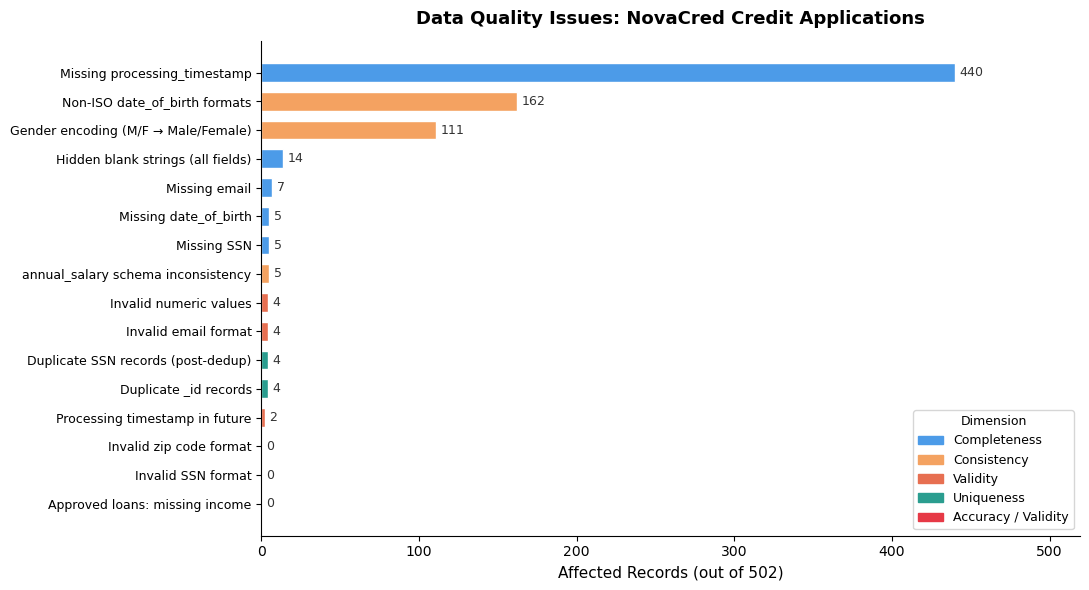

Chart saved to data/data_quality_summary.png


In [28]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# All identified issues: (label, affected_records, dimension)
issues_chart = [
    ("Missing processing_timestamp",         440, "Completeness"),
    ("Approved loans: missing income",         0, "Accuracy / Validity"),
    ("Non-ISO date_of_birth formats",        162, "Consistency"),
    ("Gender encoding (M/F → Male/Female)",  111, "Consistency"),
    ("Hidden blank strings (all fields)",     14, "Completeness"),
    ("Missing email",                          7, "Completeness"),
    ("annual_salary schema inconsistency",     5, "Consistency"),
    ("Missing SSN",                            5, "Completeness"),
    ("Missing date_of_birth",                  5, "Completeness"),
    ("Duplicate _id records",                  4, "Uniqueness"),
    ("Duplicate SSN records (post-dedup)",     4, "Uniqueness"),
    ("Invalid email format",                   4, "Validity"),
    ("Invalid numeric values",                 4, "Validity"),
    ("Invalid SSN format",              n_invalid_ssn, "Validity"),
    ("Invalid zip code format",         n_invalid_zip, "Validity"),
    ("Processing timestamp in future",   n_future_ts, "Validity"),
]

# Sort ascending so largest bar is at the top
issues_chart.sort(key=lambda x: x[1])

labels = [x[0] for x in issues_chart]
counts = [x[1] for x in issues_chart]
dims   = [x[2] for x in issues_chart]

color_map = {
    "Completeness":        "#4C9BE8",
    "Consistency":         "#F4A261",
    "Validity":            "#E76F51",
    "Uniqueness":          "#2A9D8F",
    "Accuracy / Validity": "#E63946",
}
bar_colors = [color_map[d] for d in dims]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(labels, counts, color=bar_colors, edgecolor="white", height=0.65)

# Value labels
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
            str(count), va="center", fontsize=9, color="#333333")

# Legend
legend_patches = [mpatches.Patch(color=c, label=d) for d, c in color_map.items()]
ax.legend(handles=legend_patches, title="Dimension", loc="lower right",
          fontsize=9, title_fontsize=9)

ax.set_xlabel("Affected Records (out of 502)", fontsize=11)
ax.set_title("Data Quality Issues: NovaCred Credit Applications",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlim(0, max(counts) * 1.18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.show()
print("Chart saved to data/data_quality_summary.png")

### 3.2 Data Cleaning Summary

Before export, the following cleaning steps were applied to produce `df_final`:

| Step | Description |
|------|-------------|
| Hidden blanks | Replaced 14 empty-string fields with `NaN` so completeness checks reflect true missingness |
| Duplicates | Removed 2 duplicate records by `_id` (RESUBMISSION → keep latest, else keep most complete); then 2 by SSN with the same rule |
| Schema merge | Unified `annual_income` and `annual_salary` into `financials.annual_income` |
| Type coercion | Standardized `financials.annual_income` to numeric |
| Invalid numerics | Set negative credit_history_months, negative savings_balance, and DTI outside [0, 1.5] to NaN |
| Invalid email | Set invalid email format values to NaN |
| Invalid SSN | Set non-null SSN values that do not match `XXX-XX-XXXX` to NaN |
| Invalid zip | Set invalid US zip code format values to NaN |
| Gender | Normalized `M`/`F` to `Male`/`Female` |
| DOB | Normalized date-of-birth to `YYYY-MM-DD` format |

On the final 498 rows, completeness holds: no records missing ≥2 key financial fields; required and conditional completeness checks pass.

The cleaned dataset is ready for downstream bias analysis (Notebook 02) and privacy assessment (Notebook 03).

<a id='4-export-cleaned-dataset'></a>

# 4. Export Cleaned Dataset

In [29]:
OUTPUT_PATH = Path("../data/credit_applications_clean_final.csv")
df_final.to_csv(OUTPUT_PATH, index=False)
print("Saved:", OUTPUT_PATH)
print("Rows:", len(df_final))

Saved: ../data/credit_applications_clean_final.csv
Rows: 498
